# LeNet-5 — LeCun et al. (1998), explained

Paper: *Gradient-Based Learning Applied to Document Recognition*, Proc. IEEE 86(11), Nov 1998.

Goal of this notebook: **understand the architecture**, not to build a framework.
Anything PyTorch already provides (`nn.Conv2d`, `nn.AvgPool2d`, `CrossEntropyLoss`, `SGD`,
`DataLoader`) is used as-is.

Here the paper's digit-recognition task is swapped for **individual tiger identification** on the
[ATRW](https://cvwc2019.github.io/challenge.html) re-ID dataset: given a photo of a tiger, name
*which* of 107 known tigers it is. Same architecture, a much harder problem — natural RGB photos,
cluttered backgrounds, pose variation, and only ~15 training photos per tiger on average.

**Layout**
1. Load the data
2. Helper functions, and why each one exists
3. The architecture — every layer, and the training step line by line
4. Train
5. Predict and validate
6. Glossary

**What the paper specifies** (kept): 32×32 input, C1→S2→C3→S4→C5→F6→output,
6/16/120/84 units, 5×5 kernels, 2×2 sub-sampling, `tanh` squashing, ~60k parameters, 20 passes.

**Where this simplifies / adapts** (four places, on purpose):
- Paper's sub-sampling has a trainable coefficient + bias per map. Here: plain `nn.AvgPool2d`.
- Paper's C3 connects each of the 16 maps to only *some* of the 6 S2 maps. Here: full `nn.Conv2d`.
- Paper's output is 10 Euclidean RBF units with a hand-designed loss. Here: `nn.Linear` +
  `CrossEntropyLoss`, which is what everyone uses today.
- Paper's input is 1-channel greyscale digits, 10 classes. Here: **3-channel RGB tiger photos,
  107 classes** — C1 takes 3 input channels instead of 1, and the output layer has 107 units
  instead of 10. Everything else in the architecture is untouched.

# Section 1 — Loading the data

**ATRW (Amur Tiger Re-identification in the Wild), reid split**: photos of Amur tigers cropped
around the animal, each tagged with the identity of the tiger in it.

```
benchmarks/atrw_dataset_reid_tiger/
├── atrw_anno_reid_train/reid_list_train.csv   id, filename  (labelled)
├── atrw_reid_train/train/*.jpg                labelled + extra unlabelled crops
├── atrw_anno_reid_test/reid_list_test.csv     filename only (no id — used for the
│                                               official retrieval leaderboard, not
│                                               classification, so it's no use here)
└── atrw_reid_test/test/*.jpg
```

Two details this notebook works around:
- The train **folder** has 3,392 images but the train **CSV** only labels 1,887 of them (the
  rest are unlabelled crops used elsewhere in ATRW, e.g. pose estimation). We only use the
  1,887 labelled rows.
- The official test CSV has no identity labels. So "test" here means a held-out **validation
  split carved out of the labelled training rows** (stratified by tiger id), not the
  `atrw_reid_test` folder — there is no ground truth to score against there.

Two things happen to every image before it reaches the network, same idea as the paper's
MNIST preprocessing:
- **Resize to 32×32.** The paper pads 28×28 digits to 32×32 so a stroke end-point sits in the
  centre of a top-layer receptive field. Tiger photos vary wildly in size and aspect ratio, so
  here the whole crop is resized (not padded) down to the network's native 32×32 input.
- **Normalise.** Pixel values are scaled from `0..255` to roughly `-1..1`, keeping inputs
  centred near zero so gradients behave well — the same motivation as the paper's `-0.1..1.175`
  rescaling, just with today's convention.

In [1]:
import csv
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)

DATA_ROOT = Path("benchmarks/atrw_dataset_reid_tiger")
TRAIN_IMG_DIR = DATA_ROOT / "atrw_reid_train" / "train"
TRAIN_CSV = DATA_ROOT / "atrw_anno_reid_train" / "reid_list_train.csv"

print("torch", torch.__version__, "| device:", DEVICE)

torch 2.12.1+cu126 | device: cuda


In [2]:
NORM_MEAN, NORM_STD = 0.5, 0.5   # maps 0..1 -> -1..1, paper's zero-centring idea, RGB version

transform = transforms.Compose([
    transforms.Resize((32, 32)),                 # any crop size -> the network's native input
    transforms.ToTensor(),                       # PIL -> (3,32,32) float in 0..1
    transforms.Normalize([NORM_MEAN] * 3, [NORM_STD] * 3),
])


def read_labels(csv_path):
    """CSV rows are 'id,filename' -> [(filename, id), ...]."""
    rows = []
    with open(csv_path, newline="") as f:
        for tiger_id, filename in csv.reader(f):
            rows.append((filename, int(tiger_id)))
    return rows


class TigerReIDDataset(Dataset):
    """One row = one photo of one tiger. Loads and transforms lazily, like any real dataset
    (unlike MNIST, these images don't fit comfortably as one big in-memory tensor)."""

    def __init__(self, samples, img_dir, class_to_idx, transform):
        self.samples = samples                   # [(filename, tiger_id), ...]
        self.img_dir = img_dir
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        filename, tiger_id = self.samples[i]
        img = Image.open(self.img_dir / filename).convert("RGB")
        return self.transform(img), self.class_to_idx[tiger_id]


def stratified_split(rows, val_fraction=0.15, seed=0):
    """Hold out val_fraction of EACH tiger's photos, so every identity appears in both splits
    (a plain random split could leave a rare tiger with zero training photos)."""
    import random
    by_id = {}
    for filename, tiger_id in rows:
        by_id.setdefault(tiger_id, []).append(filename)

    rng = random.Random(seed)
    train_rows, val_rows = [], []
    for tiger_id, files in by_id.items():
        files = files[:]
        rng.shuffle(files)
        n_val = max(1, round(len(files) * val_fraction))
        for f in files[:n_val]:
            val_rows.append((f, tiger_id))
        for f in files[n_val:]:
            train_rows.append((f, tiger_id))
    return train_rows, val_rows


def load_data():
    rows = read_labels(TRAIN_CSV)                                # 1,887 labelled (filename, id) pairs
    tiger_ids = sorted({tiger_id for _, tiger_id in rows})        # 107 real tiger ids, e.g. 1, 10, 96...
    class_to_idx = {tid: i for i, tid in enumerate(tiger_ids)}    # -> 0..106, what CrossEntropyLoss wants

    train_rows, val_rows = stratified_split(rows, val_fraction=0.15)
    tr = TigerReIDDataset(train_rows, TRAIN_IMG_DIR, class_to_idx, transform)
    te = TigerReIDDataset(val_rows, TRAIN_IMG_DIR, class_to_idx, transform)
    return tr, te, len(tiger_ids)

In [3]:
train_ds, test_ds, N_CLASSES = load_data()

print(f"{N_CLASSES} tiger identities | train: {len(train_ds)}  val/'test': {len(test_ds)}")
x0, y0 = train_ds[0]
print("one sample:", tuple(x0.shape), "label", int(y0),
      "| pixel range", float(x0.min()), "to", float(x0.max()))

107 tiger identities | train: 1588  val/'test': 299
one sample: (3, 32, 32) label 93 | pixel range -0.4117646813392639 to 0.4431372880935669


In [4]:
# DataLoader = PyTorch's batching + shuffling. No reason to write our own.
BATCH = 64
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

xb, yb = next(iter(train_loader))
print("one batch:", tuple(xb.shape), "labels", tuple(yb.shape))

one batch: (64, 3, 32, 32) labels (64,)


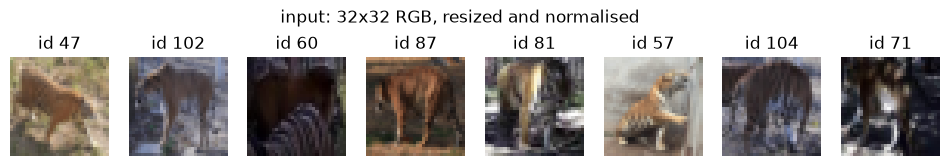

In [5]:
# Look at what we're feeding the network.
import matplotlib.pyplot as plt


def unnormalize(img):
    """(3,32,32) tensor in -1..1 -> (32,32,3) array in 0..1, for display only."""
    return (img * NORM_STD + NORM_MEAN).clamp(0, 1).permute(1, 2, 0).numpy()


fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, img, lab in zip(axes, xb, yb):
    ax.imshow(unnormalize(img)); ax.set_title(f"id {int(lab)}"); ax.axis("off")
plt.suptitle("input: 32x32 RGB, resized and normalised")
plt.show()

# Section 2 — Helper functions, and why each exists

Four small helpers. Each answers one question you will ask while iterating.

In [6]:
def count_params(model):
    """WHY: capacity. The paper's headline is that LeNet-5 gets 0.95% error with only
    ~60k free parameters, far fewer than the fully-connected nets it beats. Weight sharing
    in a conv layer is what buys that. Track this every time you change the architecture."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


@torch.no_grad()
def accuracy(model, loader):
    """WHY: the number you actually care about. Training loss can fall while accuracy
    stalls, so never judge a run by loss alone."""
    model.eval()                            # eval mode: turns off dropout/BN updates
    correct = total = 0
    for x, y in loader:
        pred = model(x.to(DEVICE)).argmax(1).cpu()   # argmax over the class scores
        correct += (pred == y).sum().item()
        total += len(y)
    return 100.0 * correct / total


@torch.no_grad()
def show_shapes(model, size=32, channels=3):
    """WHY: shape bugs are the most common bug in CNNs. Print what each layer does to the
    tensor so 32 -> 28 -> 14 -> 10 -> 5 -> 1 is visible instead of assumed."""
    x = torch.zeros(1, channels, size, size, device=DEVICE)
    print(f"{'input':22} {tuple(x.shape)}")
    for name, layer in model.named_children():
        for sub_name, sub in layer.named_children():
            x = sub(x)
            print(f"{name}.{sub_name:<18} {tuple(x.shape)}")
    return x


def plot_history(history):
    """WHY: the shape of the curves tells you what to change next. Both losses falling
    together = keep training. Train falling, test flat or rising = overfitting."""
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].plot([h["train_loss"] for h in history], marker="o")
    ax[0].set_title("training loss"); ax[0].set_xlabel("epoch")
    ax[1].plot([h["train_acc"] for h in history], marker="o", label="train")
    ax[1].plot([h["test_acc"] for h in history], marker="o", label="test")
    ax[1].set_title("accuracy (%)"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout(); plt.show()

# Section 3 — The architecture

## The shape of the idea

A convolutional network alternates two operations:

- **Convolution** — slide a small kernel (here 5×5) over the image. The *same* kernel is used
  at every position, so a feature detected in one corner is detected everywhere. That is
  **weight sharing**, and it is why the parameter count stays tiny.
- **Sub-sampling** — halve the resolution. Once a feature has been found, its *exact* position
  matters less than its rough position relative to other features. Throwing away precision
  makes the network tolerant to shifts and distortions.

Stack them and you get a "bi-pyramid": spatial size shrinks (32→28→14→10→5→1) while the number
of feature maps grows (3→6→6→16→16→120). Detail is traded for abstraction.

## The layers

| Layer | What it is | In → Out | Why |
|---|---|---|---|
| C1 | conv, 6 kernels of 5×5 | 3×32×32 → 6×28×28 | 6 colour/edge/texture detectors. 32−5+1 = 28 |
| S2 | 2×2 average pool | 6×28×28 → 6×14×14 | halve resolution; tolerate small shifts |
| C3 | conv, 16 kernels of 5×5 | 6×14×14 → 16×10×10 | combine simple features into stripe patterns, patches |
| S4 | 2×2 average pool | 16×10×10 → 16×5×5 | halve again |
| C5 | conv, 120 kernels of 5×5 | 16×5×5 → 120×1×1 | 5×5 input, 5×5 kernel → 1×1: whole-image summary |
| F6 | fully connected, 84 units | 120 → 84 | mix the 120 features |
| out | fully connected, 107 units | 84 → 107 | one score per tiger identity |

`tanh` after every layer. It is the non-linearity — without it, stacking layers would collapse
into a single linear map and depth would buy nothing.

Only two shapes change from the paper: C1 takes 3 input channels instead of 1 (RGB photos, not
greyscale digits), and the output layer has 107 units instead of 10 (107 tigers, not 10 digits).
Every other layer is untouched.

In [7]:
class LeNet5(nn.Module):
    """LeNet-5. Built from stock PyTorch layers."""

    def __init__(self, n_classes=107):
        super().__init__()

        # ---- feature extractor: learns WHAT is in the image ----
        self.features = nn.Sequential(
            # C1: 3 input channels (RGB) -> 6 feature maps, 5x5 kernel.
            # Params = 6 * (3*5*5 + 1) = 456. Still tiny, because the same kernel is reused
            # at every position (weight sharing) -- only the channel count changed from MNIST.
            nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5),   # 32x32 -> 28x28
            nn.Tanh(),                                                 # non-linearity

            # S2: average each 2x2 block. No parameters. Halves resolution, so a 1-pixel
            # shift in the input often produces no change at all in the output.
            nn.AvgPool2d(kernel_size=2),                               # 28x28 -> 14x14

            # C3: 6 maps -> 16 maps. Each new map looks at ALL 6 previous maps at once,
            # i.e. it learns combinations of the simple features C1 found.
            nn.Conv2d(6, 16, kernel_size=5),                           # 14x14 -> 10x10
            nn.Tanh(),

            # S4: halve again.
            nn.AvgPool2d(2),                                           # 10x10 -> 5x5

            # C5: kernel size == input size (5x5), so the output is 1x1 -- each of the 120
            # maps is now a single number summarising the entire image.
            nn.Conv2d(16, 120, kernel_size=5),                         # 5x5 -> 1x1
            nn.Tanh(),
        )

        # ---- classifier: turns those features into a decision ----
        self.classifier = nn.Sequential(
            nn.Flatten(),                    # (B,120,1,1) -> (B,120)
            nn.Linear(120, 84), nn.Tanh(),   # F6
            nn.Linear(84, n_classes),        # 107 raw scores ("logits"), one per tiger
        )

    def forward(self, x):
        """The forward pass: input image in, one score per tiger identity out."""
        x = self.features(x)        # image -> 120 abstract features
        return self.classifier(x)   # features -> 107 scores


model = LeNet5(n_classes=N_CLASSES).to(DEVICE)
print(model)
print("\ntrainable parameters:", count_params(model), " (paper: 60,000, on 10 grey classes)")

LeNet5(
  (features): Sequential(
    (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): Tanh()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): Tanh()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
    (7): Tanh()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=120, out_features=84, bias=True)
    (2): Tanh()
    (3): Linear(in_features=84, out_features=107, bias=True)
  )
)

trainable parameters: 70251  (paper: 60,000, on 10 grey classes)


In [8]:
# Watch the tensor shrink and deepen through the network.
show_shapes(model);

input                  (1, 3, 32, 32)
features.0                  (1, 6, 28, 28)
features.1                  (1, 6, 28, 28)
features.2                  (1, 6, 14, 14)
features.3                  (1, 16, 10, 10)
features.4                  (1, 16, 10, 10)
features.5                  (1, 16, 5, 5)
features.6                  (1, 120, 1, 1)
features.7                  (1, 120, 1, 1)
classifier.0                  (1, 120)
classifier.1                  (1, 84)
classifier.2                  (1, 84)
classifier.3                  (1, 107)


## What one training step actually does

Five lines, run once per batch. This is the whole of "learning".

```python
scores = model(x)                 # 1. FORWARD
loss   = criterion(scores, y)     # 2. MEASURE THE ERROR
optimizer.zero_grad()             # 3. CLEAR OLD GRADIENTS
loss.backward()                   # 4. BACKWARD  (back-propagation)
optimizer.step()                  # 5. UPDATE THE WEIGHTS
```

**1. Forward.** The batch flows through C1→S2→C3→S4→C5→F6→out and comes out as 10 numbers per
image. Higher = the network thinks it's more likely that digit.

**2. Loss.** `CrossEntropyLoss` compares those 10 scores against the true label and returns one
number: how wrong we were. This is the quantity we minimise. *(The 1998 paper instead used
Euclidean RBF outputs and a hand-designed criterion; cross-entropy is the modern standard and
does the same job.)*

**3. Zero the gradients.** PyTorch *accumulates* gradients into `.grad` by default. Without
this line, this batch's gradients would pile on top of the last batch's and the update would
be wrong. Forgetting it is a classic silent bug.

**4. Backward — back-propagation.** The chain rule, applied from the loss backwards through
every layer. It answers, for each weight: *if I nudge you up slightly, does the loss go up or
down, and by how much?* That answer is the **gradient**, stored in `weight.grad`.

Crucially for a conv layer, the same kernel was applied at hundreds of positions, so it
receives a gradient contribution from every one of them. PyTorch **sums** those contributions —
that is exactly what the paper describes: *"the partial derivatives of all the connections that
share a same parameter are added to form the derivative with respect to that parameter."*

**5. Update.** The optimiser moves every weight a small step in the direction that reduces the
loss: `w ← w − learning_rate × w.grad`. This is where the kernel weights improve — after enough
steps, C1's kernels have turned into stroke and edge detectors, because those are the features
that reduce the loss.

Repeat over the whole dataset = one **epoch**. The paper ran 20.

Below, one step is run manually so you can see the gradient appear and the weight move.

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9)

x, y = next(iter(train_loader))
x, y = x.to(DEVICE), y.to(DEVICE)

# Pick one kernel weight and watch it change.
w = model.features[0].weight            # C1 kernels, shape (6,3,5,5)
before = w[0, 0, 0, 0].item()
print("gradient before backward():", w.grad)          # None -- nothing computed yet

scores = model(x)                                     # 1. FORWARD
print("scores for one image (first 10 of", N_CLASSES, "):",
      scores[0, :10].detach().cpu().numpy().round(3))

loss = criterion(scores, y)                           # 2. HOW WRONG ARE WE
print("loss:", round(loss.item(), 4))

optimizer.zero_grad()                                 # 3. CLEAR
loss.backward()                                       # 4. BACKWARD -> fills .grad
print("gradient after backward():", round(w.grad[0, 0, 0, 0].item(), 6))

optimizer.step()                                      # 5. UPDATE
print(f"weight: {before:.6f} -> {w[0,0,0,0].item():.6f}  (moved against the gradient)")

gradient before backward(): None
scores for one image (first 10 of 107 ): [ 0.02   0.101  0.041 -0.135  0.069 -0.051  0.048  0.021 -0.089  0.035]
loss: 4.6785
gradient after backward(): -0.002445
weight: -0.044474 -> -0.044352  (moved against the gradient)


# Section 4 — Training

Same five lines, now in a loop over epochs. `model.train()` / `model.eval()` switch modes —
irrelevant for this network (no dropout or batch-norm), but a habit worth having.

In [10]:
def fit(model, train_loader, test_loader, epochs=10, lr=0.05):
    """Train the model. Returns a history list you can plot."""
    import csv, time
    from pathlib import Path

    log_path = Path("runs") / "n1_LeNet5_atrw" / "history.csv"
    log_path.parent.mkdir(parents=True, exist_ok=True)

    def log_epoch_csv(rec):
        """Append one epoch's metrics as a CSV row -- survives a KeyboardInterrupt mid-training."""
        write_header = not log_path.exists()
        with open(log_path, "a", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=list(rec.keys()))
            if write_header:
                writer.writeheader()
            writer.writerow(rec)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    history = []

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        model.train()                                  # training mode
        running_loss, correct, seen = 0.0, 0, 0

        for x, y in train_loader:                      # one batch at a time
            x, y = x.to(DEVICE), y.to(DEVICE)

            scores = model(x)                          # 1. forward
            loss = criterion(scores, y)                # 2. error

            optimizer.zero_grad()                      # 3. clear old gradients
            loss.backward()                            # 4. back-propagate
            optimizer.step()                           # 5. update the weights

            running_loss += loss.item() * len(y)       # bookkeeping only
            correct += (scores.argmax(1) == y).sum().item()
            seen += len(y)

        test_acc = accuracy(model, test_loader)
        rec = {"epoch": epoch,
               "train_loss": running_loss / seen,
               "train_acc": 100.0 * correct / seen,
               "test_acc": test_acc,
               "error_rate": round(100.0 - test_acc, 4),
               "epoch_time_sec": round(time.time() - epoch_start, 2)}
        history.append(rec)
        log_epoch_csv(rec)
        print(f"epoch {epoch:2d}  loss {rec['train_loss']:.4f}  "
              f"train {rec['train_acc']:.2f}%  test {rec['test_acc']:.2f}%  "
              f"({rec['epoch_time_sec']:.1f}s)")

    return history

In [11]:
model = LeNet5(n_classes=N_CLASSES).to(DEVICE)     # fresh model
# More epochs than the paper's MNIST run: fewer photos per class (~15) and 107-way
# classification take longer to shake out than 10-way digit recognition.
history = fit(model, train_loader, test_loader, epochs=20, lr=0.05)

epoch  1  loss 4.4979  train 4.91%  test 5.69%  (7.2s)
epoch  2  loss 3.9825  train 8.25%  test 9.36%  (5.3s)
epoch  3  loss 3.5138  train 14.11%  test 18.06%  (5.5s)
epoch  4  loss 3.0469  train 23.87%  test 26.76%  (4.7s)
epoch  5  loss 2.6199  train 32.87%  test 38.13%  (4.5s)
epoch  6  loss 2.2261  train 44.77%  test 39.80%  (4.4s)
epoch  7  loss 1.8678  train 53.02%  test 54.18%  (4.5s)
epoch  8  loss 1.5577  train 62.97%  test 54.18%  (4.4s)
epoch  9  loss 1.2961  train 71.28%  test 55.52%  (4.4s)
epoch 10  loss 1.1059  train 75.25%  test 61.87%  (4.4s)
epoch 11  loss 0.9091  train 79.66%  test 66.22%  (4.4s)
epoch 12  loss 0.7378  train 85.71%  test 69.23%  (4.4s)
epoch 13  loss 0.6052  train 88.48%  test 69.90%  (4.3s)
epoch 14  loss 0.5360  train 90.30%  test 68.90%  (4.3s)
epoch 15  loss 0.4291  train 93.58%  test 74.58%  (4.4s)
epoch 16  loss 0.3344  train 96.41%  test 74.58%  (4.3s)
epoch 17  loss 0.3673  train 94.27%  test 72.58%  (4.4s)
epoch 18  loss 0.2973  train 96.54%

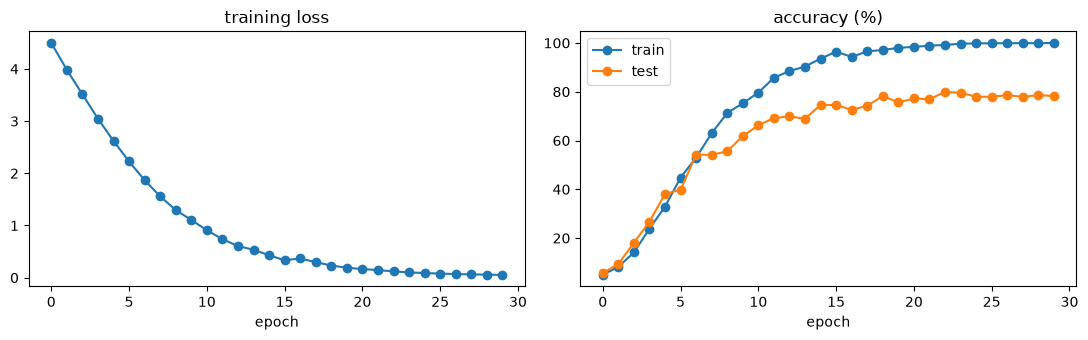

best held-out accuracy: 79.93311036789298 %
random guessing baseline: 0.93% (1 in 107)


In [12]:
plot_history(history)
print("best held-out accuracy:", max(h["test_acc"] for h in history), "%")
print(f"random guessing baseline: {100 / N_CLASSES:.2f}% (1 in {N_CLASSES})")

# Section 5 — Prediction and validation

Three checks, in increasing usefulness:
1. the raw error rate,
2. *which* digits it confuses (confusion matrix),
3. *what* it got wrong (look at the images).

Step 3 is the one that tells you what to fix.

In [13]:
@torch.no_grad()
def predict(model, x):
    """Returns (predicted class, confidence). Softmax turns raw scores into probabilities."""
    model.eval()
    probs = F.softmax(model(x.to(DEVICE)), dim=1)
    conf, pred = probs.max(1)
    return pred.cpu(), conf.cpu()


x, y = next(iter(test_loader))
pred, conf = predict(model, x[:8])
for i in range(8):
    mark = "ok " if pred[i] == y[i] else "XX "
    print(f"{mark} true tiger#{int(y[i])}  predicted tiger#{int(pred[i])}  confidence {conf[i]:.1%}")

ok  true tiger#93  predicted tiger#93  confidence 98.6%
ok  true tiger#93  predicted tiger#93  confidence 98.8%
ok  true tiger#93  predicted tiger#93  confidence 98.8%
ok  true tiger#97  predicted tiger#97  confidence 70.1%
ok  true tiger#97  predicted tiger#97  confidence 91.8%
XX  true tiger#97  predicted tiger#99  confidence 95.2%
XX  true tiger#62  predicted tiger#92  confidence 92.2%
ok  true tiger#62  predicted tiger#62  confidence 93.9%


held-out accuracy 78.26%   error rate 21.74%   misclassified 65


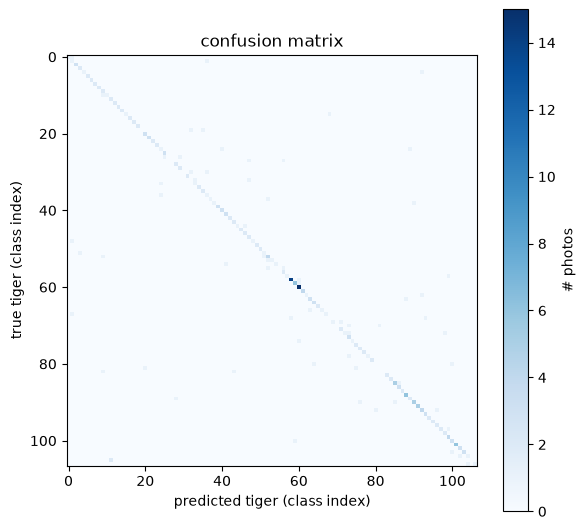

In [14]:
# Full held-out set: accuracy + confusion matrix.
@torch.no_grad()
def evaluate(model, loader, n_classes):
    model.eval()
    cm = torch.zeros(n_classes, n_classes, dtype=torch.long)   # rows = true, cols = predicted
    wrong_x, wrong_true, wrong_pred = [], [], []
    for x, y in loader:
        p = model(x.to(DEVICE)).argmax(1).cpu()
        for t, q in zip(y, p):
            cm[t, q] += 1
        bad = p != y
        if bad.any():
            wrong_x.append(x[bad]); wrong_true.append(y[bad]); wrong_pred.append(p[bad])
    acc = 100.0 * cm.diag().sum().item() / cm.sum().item()
    if wrong_x:
        wrong = (torch.cat(wrong_x), torch.cat(wrong_true), torch.cat(wrong_pred))
    else:
        wrong = (torch.empty(0), torch.empty(0), torch.empty(0))
    return acc, cm, wrong


acc, cm, wrong = evaluate(model, test_loader, N_CLASSES)
print(f"held-out accuracy {acc:.2f}%   error rate {100 - acc:.2f}%   misclassified {len(wrong[0])}")

# 107x107 is too big for per-cell numbers or tick labels, so just show the heatmap: a strong
# diagonal means the network tells tigers apart; scattered off-diagonal mass is the confusion.
fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xlabel("predicted tiger (class index)"); ax.set_ylabel("true tiger (class index)")
ax.set_title("confusion matrix")
plt.colorbar(im, ax=ax, label="# photos")
plt.tight_layout(); plt.show()

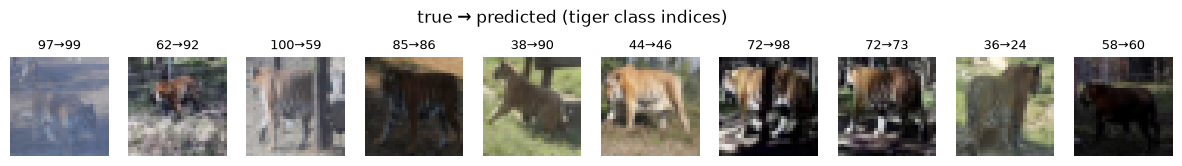

In [15]:
# Look at the mistakes. The paper does the same for MNIST (its Figure 8 shows all 82 errors);
# for tigers, expect confusions between individuals with similar stripe patterns or poses.
n = min(10, len(wrong[0]))
if n:
    fig, axes = plt.subplots(1, n, figsize=(1.5 * n, 2))
    for ax, img, t, p in zip(axes, wrong[0][:n], wrong[1][:n], wrong[2][:n]):
        ax.imshow(unnormalize(img)); ax.set_title(f"{int(t)}→{int(p)}", fontsize=9)
        ax.axis("off")
    plt.suptitle("true → predicted (tiger class indices)"); plt.show()
else:
    print("no mistakes on this run")

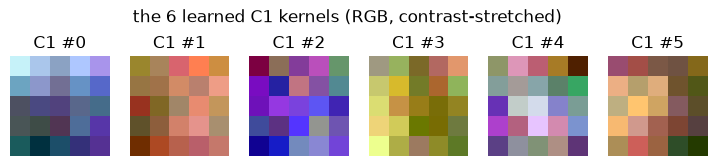

In [16]:
# What did C1 actually learn? Each 5x5x3 tile is one kernel: an RGB colour/edge detector.
# Min-max normalised per kernel for display, since raw weights aren't in 0..1.
k = model.features[0].weight.detach().cpu()          # (6, 3, 5, 5)
fig, axes = plt.subplots(1, 6, figsize=(9, 2))
for i, ax in enumerate(axes):
    tile = k[i].permute(1, 2, 0)                      # (5,5,3)
    tile = (tile - tile.min()) / (tile.max() - tile.min() + 1e-8)
    ax.imshow(tile); ax.set_title(f"C1 #{i}"); ax.axis("off")
plt.suptitle("the 6 learned C1 kernels (RGB, contrast-stretched)"); plt.show()

# Section 6 — Glossary

**Tensor** — an n-dimensional array. An image batch is a 4-D tensor `(batch, channels, height, width)`.

**Channel / feature map** — one 2-D slice of a layer's output. C1 produces 6, so it looks for 6 different things.

**Kernel / filter** — the small (5×5) grid of weights slid over the input. What the layer learns.

**Convolution** — sliding that kernel across the whole image, computing a weighted sum at each position.

**Weight sharing** — using the same kernel at every position. Why C1 needs 156 parameters instead of hundreds of thousands.

**Receptive field** — the region of the *original* image that one unit can see. Grows layer by layer.

**Stride** — how far the kernel moves per step (1 here). **Padding** — pixels added at the border (2 here, to reach 32×32).

**Sub-sampling / pooling** — shrinking the map (2×2 → 1 value). Buys tolerance to small shifts.

**Activation / non-linearity** — `tanh` here. Without it, stacked layers collapse into one linear layer.

**Fully connected (dense) layer** — every input connects to every output. No weight sharing, so parameter-hungry.

**Logits** — the raw output scores, before any normalisation. **Softmax** — turns logits into probabilities summing to 1.

**Loss function** — one number saying how wrong the prediction is. Cross-entropy here.

**Gradient** — the derivative of the loss w.r.t. a weight: which way, and how hard, to move it.

**Back-propagation** — the chain rule applied backwards through the network to get every gradient in one pass.

**Optimiser** — the rule that turns gradients into weight updates. **SGD** = `w ← w − lr × grad`. **Momentum** — keeps some of the previous step, smoothing the path.

**Learning rate** — the step size. Too big overshoots, too small crawls.

**Epoch** — one full pass over the training set. **Batch** — the group of samples processed before one update.

**Parameter** — a learnable number (weight or bias). **Hyperparameter** — a number *you* choose (learning rate, batch size).

**Training / test set** — data used to fit vs. data held out to measure honestly. **Overfitting** — memorising the training set; train accuracy climbs while test accuracy does not.

**Confusion matrix** — a table of true class vs. predicted class. The off-diagonal entries are your errors.

**Accuracy / error rate** — fraction right / fraction wrong. The paper reports error rate: 0.95%.

**`model.train()` / `model.eval()`** — switches layers that behave differently in training vs. inference (dropout, batch-norm). Harmless but correct habit here.

**`zero_grad()`** — clears `.grad`, which PyTorch otherwise accumulates across batches.

**`torch.no_grad()`** — turns off gradient tracking. Use for evaluation: faster and uses less memory.

## Next steps

Change one thing, re-run `fit`, compare the held-out accuracy:

| Try | What it tells you |
|---|---|
| `nn.ReLU()` instead of `nn.Tanh()` | what 25 years of activation-function work is worth |
| `nn.MaxPool2d(2)` instead of `nn.AvgPool2d(2)` | max vs. average sub-sampling |
| `torch.optim.Adam(..., lr=1e-3)` instead of SGD | how much of the gain is just the optimiser |
| double the kernels: `Conv2d(3, 12, 5)`, `Conv2d(12, 32, 5)` | more capacity — does it help, or overfit on ~15 photos/tiger? |
| add `transforms.RandomHorizontalFlip()` to `transform` | does more effective data help more than a bigger model, with this little data? |
| bump `Resize` to 64×64 and widen C1's kernel accordingly | does the network lose identity-distinguishing detail at 32×32? |

Change **one** at a time, and write down the number each time. That's how you learn which part
of the architecture is actually carrying the result.

## Save results

Persist the trained model and validation metrics to `runs/<name>/`, so this run survives a kernel restart and can be compared against the other notebooks later.


In [17]:
# Save the trained model + validation results into runs/n1_LeNet5_atrw/, so this run isn't lost.
import json
from pathlib import Path

RUN_DIR = Path("runs") / "n1_LeNet5_atrw"
RUN_DIR.mkdir(parents=True, exist_ok=True)

torch.save({"model_state": model.state_dict(), "history": history}, RUN_DIR / "model.pt")

with open(RUN_DIR / "metrics.json", "w") as f:
    json.dump({
        "held_out_accuracy": acc,
        "best_test_acc_during_training": max(h["test_acc"] for h in history) if history else None,
        "misclassified": len(wrong[0]),
        "history": history,
    }, f, indent=2)

print("saved model + metrics to", RUN_DIR.resolve())


saved model + metrics to C:\Users\eeuma\Desktop\PhD Research Codes\5_systematically_move_to_best_architecture\runs\n1_LeNet5_atrw
